<a href="https://colab.research.google.com/github/alvarocandela93/Git-training/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Set up Environment & Load Data

In [1]:
# Import data manipulation and math libraries
import pandas as pd
import numpy as np

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import scikit-learn tools for splitting and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

#Mount Google Drive
from google.colab import drive
from google.colab import files
drive.mount('/content/drive')

Mounted at /content/drive


**Load Data**

In [2]:
# 1. Load the data
file_string = "/content/drive/MyDrive/brazilian_malware.csv"
df = pd.read_csv(file_string)

# Display the first few rows to ensure it loaded correctly
display(df.head())


,BaseOfCode,BaseOfData,Characteristics,DllCharacteristics,Entropy,FileAlignment,FirstSeenDate,Identify,ImageBase,ImportedDlls,...,PointerToSymbolTable,SHA1,Size,SizeOfCode,SizeOfHeaders,SizeOfImage,SizeOfInitializedData,SizeOfOptionalHeader,SizeOfUninitializedData,TimeDateStamp
0,4096,69632,783,0,5.981249,512,1970-01-01,powerbasic/win 8.00,4194304,comdlg32.dll gdi32.dll kernel32.dll ole32.dll ...,...,0,b0068836a40e6a43c6b546fcb709237e5aa223d1,76288,64855,1024,86016,2560,224,1500,12345
1,4096,1851392,783,0,6.081747,512,1970-01-01,NaN,4194304,comctl32.dll comdlg32.dll gdi32.dll kernel32.d...,...,0,5741708cd785f13b44267883e3f2fd2fa51fc23f,2558464,1843888,1024,2600960,500348,224,21476,0
2,4096,40960,783,0,5.586422,512,1970-01-01,NaN,4194304,comdlg32.dll kernel32.dll msvcrt.dll msvcrt.dl...,...,0,507fe5d8244f33d29d427468efca4ce406f23666,178688,33792,1024,33759232,177664,224,33557504,0
3,1359872,2138112,783,0,7.969464,512,1970-01-01,"upx 2.93 - 3.00 [lzma] -> markus oberhumer, la...",4194304,kernel32.dll advapi32.dll comdlg32.dll gdi32.d...,...,0,e51a7811464be1acadf6e72ba3a66aba0da438cd,806816,778240,4096,2166784,28672,224,1355776,0
4,4096,40960,783,32768,7.999900,512,1970-01-01,NaN,4194304,advapi32.dll comctl32.dll gdi32.dll kernel32.d...,...,0,0e046d9903c313ffeeb0d6392335437fe881b1f5,50689096,35840,1024,303104,38912,224,110080,0


**Data Exploration**

In [3]:
#Describe data
df.describe()

,BaseOfCode,BaseOfData,Characteristics,DllCharacteristics,Entropy,FileAlignment,ImageBase,Label,Machine,Magic,...,PE_TYPE,PointerToSymbolTable,Size,SizeOfCode,SizeOfHeaders,SizeOfImage,SizeOfInitializedData,SizeOfOptionalHeader,SizeOfUninitializedData,TimeDateStamp
count,5.018100e+04,5.018100e+04,50181.000000,50181.000000,50181.000000,50181.000000,5.018100e+04,50181.000000,50181.000000,50181.0,...,50181.0,5.018100e+04,5.018100e+04,5.018100e+04,50181.000000,5.018100e+04,5.018100e+04,50181.0,5.018100e+04,5.018100e+04
mean,1.724954e+05,8.834009e+05,18939.747016,10238.381080,6.694522,823.511050,1.636863e+08,0.579203,332.078874,267.0,...,267.0,5.513845e+05,6.895724e+06,6.789796e+05,1595.302286,2.476806e+06,1.556195e+06,224.0,1.728905e+05,1.223333e+09
std,3.721744e+06,7.145701e+06,16567.684820,15085.745309,1.145355,1012.754781,4.065986e+08,0.493692,3.074768,0.0,...,0.0,3.389692e+07,5.724471e+07,1.572283e+06,1263.993734,1.775206e+07,4.401886e+07,0.0,3.730825e+06,2.872506e+08
min,0.000000e+00,0.000000e+00,2.000000,0.000000,0.011174,32.000000,6.553600e+04,0.000000,332.000000,267.0,...,267.0,0.000000e+00,2.560000e+03,0.000000e+00,512.000000,2.944000e+03,0.000000e+00,224.0,0.000000e+00,0.000000e+00
25%,4.096000e+03,6.144000e+04,291.000000,0.000000,6.210294,512.000000,4.194304e+06,0.000000,332.000000,267.0,...,267.0,0.000000e+00,1.408000e+05,5.324800e+04,1024.000000,1.433600e+05,1.331200e+04,224.0,0.000000e+00,1.191272e+09
50%,4.096000e+03,3.358720e+05,8450.000000,1.000000,6.615470,512.000000,4.194304e+06,1.000000,332.000000,267.0,...,267.0,0.000000e+00,5.723040e+05,2.688000e+05,1024.000000,5.242880e+05,7.987200e+04,224.0,0.000000e+00,1.367470e+09
75%,4.096000e+03,7.823360e+05,33167.000000,32768.000000,7.850877,512.000000,1.093140e+08,1.000000,332.000000,267.0,...,267.0,0.000000e+00,1.981952e+06,6.906880e+05,1024.000000,1.466368e+06,2.959360e+05,224.0,0.000000e+00,1.421637e+09
max,2.457108e+08,9.415107e+08,44430.000000,60708.000000,8.000000,8192.000000,3.212837e+09,1.000000,452.000000,267.0,...,267.0,2.425393e+09,3.986104e+09,9.786982e+07,50176.000000,1.473761e+09,4.294804e+09,224.0,2.457068e+08,4.107316e+09


In [4]:
#Review data and empty values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50181 entries, 0 to 50180
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   BaseOfCode               50181 non-null  int64  
 1   BaseOfData               50181 non-null  int64  
 2   Characteristics          50181 non-null  int64  
 3   DllCharacteristics       50181 non-null  int64  
 4   Entropy                  50181 non-null  float64
 5   FileAlignment            50181 non-null  int64  
 6   FirstSeenDate            50181 non-null  object 
 7   Identify                 35958 non-null  object 
 8   ImageBase                50181 non-null  int64  
 9   ImportedDlls             50181 non-null  object 
 10  ImportedSymbols          50181 non-null  object 
 11  Label                    50181 non-null  int64  
 12  Machine                  50181 non-null  int64  
 13  Magic                    50181 non-null  int64  
 14  NumberOfRvaAndSizes   

In [5]:
# Check class balance before cleaning
print("\nLabel counts BEFORE cleaning:")
print(df['Label'].value_counts())


Label counts BEFORE cleaning:
Label
1    29065
0    21116
Name: count, dtype: int64


# Initial Cleaning

In [9]:
# 1. Clean the Label column: Keep only rows where Label is exactly 0 or 1
df = df[df['Label'].isin([0, 1])]

# Ensure the Label column is treated as an integer
df['Label'] = df['Label'].astype(int)

# 2. Drop irrelevant and zero-variance columns
# 'Magic' and 'PE_TYPE' never change.
# 'ImportedDlls', 'ImportedSymbols', 'SHA1', 'Identify', and 'FirstSeenDate' are text/hashes.
cols_to_drop = [
    'Magic', 'PE_TYPE',
    'ImportedDlls', 'ImportedSymbols',
    'SHA1', 'Identify', 'FirstSeenDate'
]

# We use a list comprehension to only drop columns that actually exist in the dataframe
# (prevents errors if a column was already dropped or misspelled)
existing_cols_to_drop = [col for col in cols_to_drop if col in df.columns]
df = df.drop(columns=existing_cols_to_drop)

print("\nLabel counts AFTER cleaning:")
print(df['Label'].value_counts())
print(f"\nRemaining columns: {df.shape[1]}")


Label counts AFTER cleaning:
Label
1    29065
0    21116
Name: count, dtype: int64

Remaining columns: 21


# Train/Test Split

In [10]:
# Separate the input features (X) and the target variable (y)
X = df.drop('Label', axis=1)
y = df['Label']

# Perform the 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,      # Ensures the 80/20 split maintains the same malware/goodware ratio
    random_state=42  # Locks the random seed for reproducibility
)

# Print the shapes to verify
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (40144, 20)
Testing features shape: (10037, 20)


# Preprocessing (Imputation & Scaling)

In [13]:
# Define the preprocessing pipeline
preprocessing_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Fill missing values with the median
    ('scaler', StandardScaler())                   # Scale features to mean=0, variance=1
])

# Fit the pipeline on the training data AND transform it
# Notice we only use X_train here!
X_train_processed = preprocessing_pipeline.fit_transform(X_train)

# Transform the test data using the rules learned from the training data
X_test_processed = preprocessing_pipeline.transform(X_test)

print("Preprocessing complete! Data is now scaled and ready for modeling.")

# Verify the scaling and imputation
display(pd.DataFrame(X_train_processed, columns=X_train.columns).describe().round(2))

Preprocessing complete! Data is now scaled and ready for modeling.


,BaseOfCode,BaseOfData,Characteristics,DllCharacteristics,Entropy,FileAlignment,ImageBase,Machine,NumberOfRvaAndSizes,NumberOfSections,NumberOfSymbols,PointerToSymbolTable,Size,SizeOfCode,SizeOfHeaders,SizeOfImage,SizeOfInitializedData,SizeOfOptionalHeader,SizeOfUninitializedData,TimeDateStamp
count,40144.00,40144.00,40144.00,40144.00,40144.00,40144.00,40144.00,40144.00,40144.00,40144.00,40144.00,40144.00,40144.00,40144.00,40144.00,40144.00,40144.00,40144.0,40144.00,40144.00
mean,0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00,0.0,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.0,1.00,1.00
min,-0.05,-0.12,-1.14,-0.68,-5.84,-0.78,-0.40,-0.03,-0.02,-1.88,-0.01,-0.02,-0.12,-0.43,-0.86,-0.13,-0.03,0.0,-0.05,-4.27
25%,-0.05,-0.11,-1.13,-0.68,-0.43,-0.31,-0.39,-0.03,-0.02,-0.68,-0.01,-0.02,-0.12,-0.40,-0.45,-0.13,-0.03,0.0,-0.05,-0.11
50%,-0.05,-0.07,-0.63,-0.68,-0.07,-0.31,-0.39,-0.03,-0.02,-0.29,-0.01,-0.02,-0.11,-0.26,-0.45,-0.11,-0.03,0.0,-0.05,0.50
75%,-0.05,-0.01,0.86,1.49,1.01,-0.31,-0.14,-0.03,-0.02,0.90,-0.01,-0.02,-0.08,0.01,-0.45,-0.05,-0.03,0.0,-0.05,0.69
max,74.22,125.10,1.54,3.35,1.14,7.27,7.45,37.21,80.78,6.46,143.94,69.95,69.09,61.50,38.34,81.04,98.01,0.0,73.98,9.55


# Models

Installations and imports

In [14]:
# Install CatBoost (XGBoost and LightGBM are already pre-installed in Colab)
!pip install catboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Evaluation Metrics & Cross Validation
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from sklearn.base import BaseEstimator, ClassifierMixin

# PyTorch for our Neural Network (MLP)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Set a global seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 4.9 MB/s eta 0:00:00


Pytorch MLP Wrapper

In [15]:
# Define the Neural Network Architecture
class SimpleMLP(nn.Module):
    def __init__(self, input_dim):
        super(SimpleMLP, self).__init__()
        # A simple 3-layer network
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2), # Dropout prevents overfitting by randomly turning off neurons
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid() # Squashes output between 0 and 1 (perfect for binary probabilities)
        )

    def forward(self, x):
        return self.network(x)

# Wrap it to behave like a Scikit-Learn model
class PyTorchClassifierWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, input_dim, epochs=20, batch_size=64, lr=0.001):
        self.input_dim = input_dim
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.model = None

    def fit(self, X, y):
        self.model = SimpleMLP(self.input_dim)
        criterion = nn.BCELoss() # Binary Cross Entropy Loss
        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)

        # Convert data to PyTorch Tensors
        X_tensor = torch.FloatTensor(X)
        y_tensor = torch.FloatTensor(y.values).unsqueeze(1)
        dataset = TensorDataset(X_tensor, y_tensor)
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        self.model.train()
        for epoch in range(self.epochs):
            for batch_X, batch_y in loader:
                optimizer.zero_grad()
                outputs = self.model(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
        return self

    def predict_proba(self, X):
        self.model.eval()
        with torch.no_grad():
            X_tensor = torch.FloatTensor(X)
            probs = self.model(X_tensor).numpy()
        # Scikit-learn expects probabilities for both class 0 and class 1
        return np.hstack((1 - probs, probs))

    def predict(self, X):
        probs = self.predict_proba(X)[:, 1]
        return (probs >= 0.5).astype(int)

Modular evaluation Function

In [16]:
def train_eval_model(model, X, y, cv_splits=5):
    """
    Evaluates a model using Stratified K-Fold Cross Validation.
    Returns the mean and standard deviation of AUC and Accuracy.
    """
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=RANDOM_SEED)

    # We use scikit-learn's built in cross_validate for speed and simplicity
    scores = cross_validate(
        model, X, y,
        cv=cv,
        scoring={'auc': 'roc_auc', 'accuracy': 'accuracy'},
        return_train_score=False,
        n_jobs=1 # Set to 1 to avoid issues with PyTorch multiprocessing
    )

    # Calculate Mean and Std Dev
    results = {
        'AUC_Mean': np.mean(scores['test_auc']),
        'AUC_Std': np.std(scores['test_auc']),
        'Acc_Mean': np.mean(scores['test_accuracy']),
        'Acc_Std': np.std(scores['test_accuracy'])
    }
    return results

Run all models

In [17]:
# 1. Initialize all models
input_features = X_train_processed.shape[1]

models = {
    "Logistic Regression": LogisticRegression(random_state=RANDOM_SEED, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_SEED),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_SEED),
    "PyTorch MLP": PyTorchClassifierWrapper(input_dim=input_features),
    "XGBoost": XGBClassifier(random_state=RANDOM_SEED, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(random_state=RANDOM_SEED, verbose=-1),
    "CatBoost": CatBoostClassifier(random_state=RANDOM_SEED, verbose=0) # verbose=0 hides training text
}

# 2. Run the evaluation loop
results_list = []

print("Starting model bake-off! This may take a few minutes...\n")
for name, model in models.items():
    print(f"Training and evaluating: {name}...")
    metrics = train_eval_model(model, X_train_processed, y_train)
    metrics['Model'] = name
    results_list.append(metrics)

# 3. Create a DataFrame and sort by best AUC
results_df = pd.DataFrame(results_list)
# Reorder columns for readability
results_df = results_df[['Model', 'AUC_Mean', 'AUC_Std', 'Acc_Mean', 'Acc_Std']]
results_df = results_df.sort_values(by='AUC_Mean', ascending=False).reset_index(drop=True)

print("\n=== CROSS-VALIDATION RESULTS ===")
display(results_df)

# 4. Automatically identify the best model
best_model_name = results_df.iloc[0]['Model']
best_model_instance = models[best_model_name]
print(f"\n🏆 The Best Model is: {best_model_name}!")

Starting model bake-off! This may take a few minutes...

Training and evaluating: Logistic Regression...
Training and evaluating: Decision Tree...
Training and evaluating: Random Forest...
Training and evaluating: PyTorch MLP...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
                ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_response.py", line 235, in _get_response_values
    raise ValueError(
ValueError: PyTorchClassifierWrapper should either be a classifier to be used with response_method=predict_proba or the response_method should be

Training and evaluating: XGBoost...
Training and evaluating: LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Training and evaluating: CatBoost...

=== CROSS-VALIDATION RESULTS ===


,Model,AUC_Mean,AUC_Std,Acc_Mean,Acc_Std
0,XGBoost,0.997994,0.000406,0.986573,0.001172
1,Random Forest,0.997645,0.000686,0.987694,0.001046
2,CatBoost,0.997585,0.000402,0.985178,0.001163
3,LightGBM,0.997537,0.000447,0.983186,0.001136
4,Decision Tree,0.977530,0.001611,0.978453,0.001486
5,Logistic Regression,0.877219,0.003550,0.813895,0.004330
6,PyTorch MLP,NaN,NaN,0.948859,0.002591



🏆 The Best Model is: XGBoost!


Final Test Evaluation & Confusion Matrix

Training the XGBoost on the full training dataset...

=== FINAL TEST SET PERFORMANCE ===
Test AUC:      0.9976
Test Accuracy: 0.9871


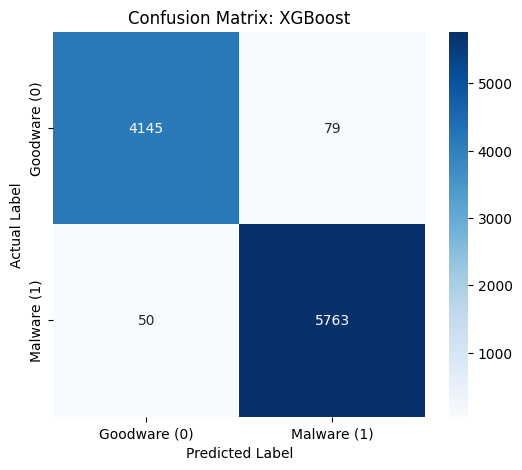

In [18]:
print(f"Training the {best_model_name} on the full training dataset...")

# 1. Train the best model on ALL training data
best_model_instance.fit(X_train_processed, y_train)

# 2. Make predictions on the completely unseen Test Data
# (Make sure we use the processed test data: X_test_processed)
test_preds = best_model_instance.predict(X_test_processed)
test_probs = best_model_instance.predict_proba(X_test_processed)[:, 1]

# 3. Calculate Final Metrics
final_auc = roc_auc_score(y_test, test_probs)
final_acc = accuracy_score(y_test, test_preds)

print("\n=== FINAL TEST SET PERFORMANCE ===")
print(f"Test AUC:      {final_auc:.4f}")
print(f"Test Accuracy: {final_acc:.4f}")

# 4. Plot the Confusion Matrix
cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Goodware (0)', 'Malware (1)'],
            yticklabels=['Goodware (0)', 'Malware (1)'])
plt.title(f'Confusion Matrix: {best_model_name}')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()